In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import ndtr
from matplotlib.patches import Polygon

In [ ]:
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### Problem 1

In [ ]:
mu1 = 10
sigma1 = 2
x1 = 12

In [ ]:
prob1 = stats.norm.cdf(x1, mu1, sigma1)

print(f"P(X < {x1}) = {prob1:.4f}")

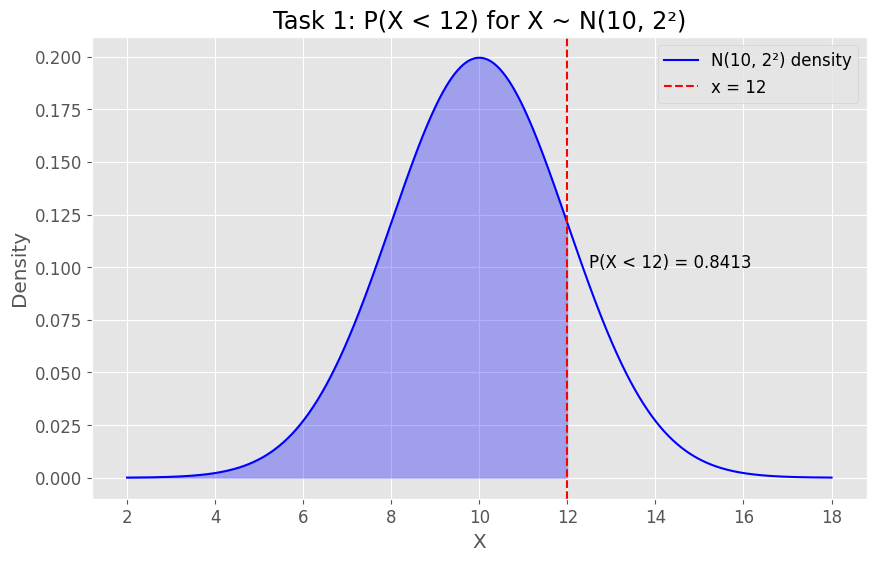

In [5]:
fig1, ax1 = plt.subplots()

x_values = np.linspace(mu1 - 4 * sigma1, mu1 + 4 * sigma1, 1000)
y_values = stats.norm.pdf(x_values, mu1, sigma1)

ax1.plot(x_values, y_values, 'b-', label='N(10, 2²) density')

x_fill = np.linspace(mu1 - 4 * sigma1, x1, 100)
y_fill = stats.norm.pdf(x_fill, mu1, sigma1)
ax1.fill_between(x_fill, y_fill, alpha=0.3, color='blue')

ax1.axvline(x=x1, color='r', linestyle='--', label=f'x = {x1}')

ax1.text(x1 + 0.5, 0.1, f'P(X < {x1}) = {prob1:.4f}', fontsize=12)

ax1.set_xlabel('X')
ax1.set_ylabel('Density')
ax1.set_title(f'Task 1: P(X < {x1}) for X ~ N({mu1}, {sigma1}²)')
ax1.legend()

### Problem 2

In [6]:
mu2 = 50
sigma2 = 10
prob2 = 0.05

In [7]:
x2 = stats.norm.ppf(prob2, mu2, sigma2)
print(f"Value of x where P(X < x) = {prob2} is {x2:.4f}")

Value of x where P(X < x) = 0.05 is 33.5515


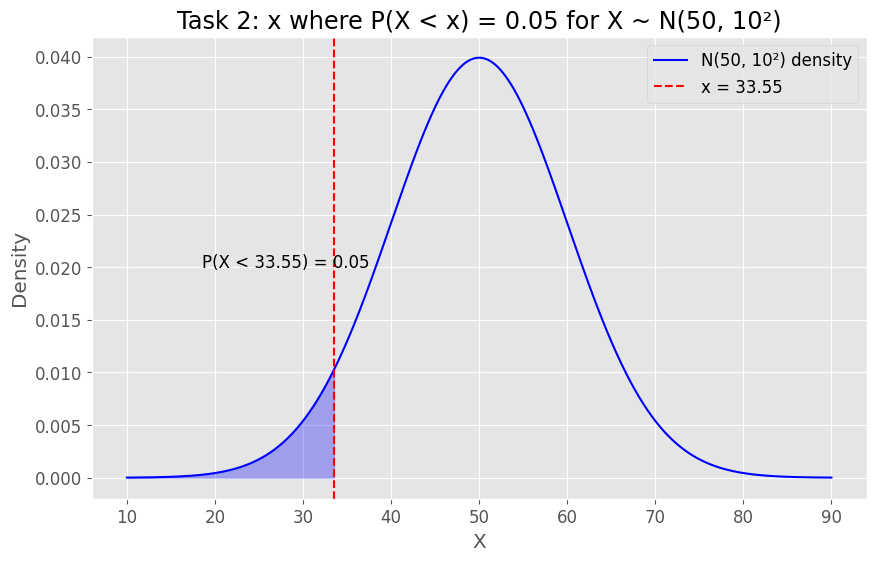

In [8]:
fig2, ax2 = plt.subplots()

x_values = np.linspace(mu2 - 4 * sigma2, mu2 + 4 * sigma2, 1000)
y_values = stats.norm.pdf(x_values, mu2, sigma2)

ax2.plot(x_values, y_values, 'b-', label='N(50, 10²) density')

x_fill = np.linspace(mu2 - 4 * sigma2, x2, 100)
y_fill = stats.norm.pdf(x_fill, mu2, sigma2)
ax2.fill_between(x_fill, y_fill, alpha=0.3, color='blue')

ax2.axvline(x=x2, color='r', linestyle='--', label=f'x = {x2:.2f}')

ax2.text(x2 - 15, 0.02, f'P(X < {x2:.2f}) = {prob2}', fontsize=12)

ax2.set_xlabel('X')
ax2.set_ylabel('Density')
ax2.set_title(f'Task 2: x where P(X < x) = {prob2} for X ~ N({mu2}, {sigma2}²)')
ax2.legend()

### Problem 3

In [9]:
mu3 = 100
sigma3 = 15
x3_lower = 85
x3_upper = 115

In [10]:
prob3 = stats.norm.cdf(x3_upper, mu3, sigma3) - stats.norm.cdf(x3_lower, mu3, sigma3)
print(f"P({x3_lower} < X < {x3_upper}) = {prob3:.4f}")

P(85 < X < 115) = 0.6827


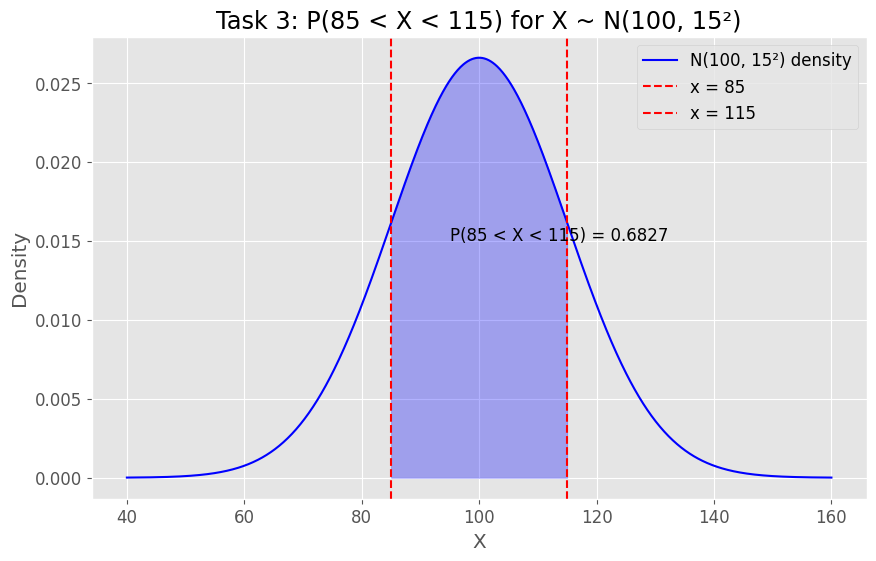

In [11]:
fig3, ax3 = plt.subplots()

x_values = np.linspace(mu3 - 4 * sigma3, mu3 + 4 * sigma3, 1000)
y_values = stats.norm.pdf(x_values, mu3, sigma3)

ax3.plot(x_values, y_values, 'b-', label='N(100, 15²) density')

x_fill = np.linspace(x3_lower, x3_upper, 100)
y_fill = stats.norm.pdf(x_fill, mu3, sigma3)
ax3.fill_between(x_fill, y_fill, alpha=0.3, color='blue')

ax3.axvline(x=x3_lower, color='r', linestyle='--', label=f'x = {x3_lower}')
ax3.axvline(x=x3_upper, color='r', linestyle='--', label=f'x = {x3_upper}')

ax3.text(mu3 - 5, 0.015, f'P({x3_lower} < X < {x3_upper}) = {prob3:.4f}', fontsize=12)

ax3.set_xlabel('X')
ax3.set_ylabel('Density')
ax3.set_title(f'Task 3: P({x3_lower} < X < {x3_upper}) for X ~ N({mu3}, {sigma3}²)')
ax3.legend()

### Problem 4

In [12]:
mu0 = 120
sample_mean = 118
sample_std = 5
sample_size = 100
alpha = 0.01

In [18]:
# standard error
se = sample_std / np.sqrt(sample_size)

# test statistic
z_stat = (sample_mean - mu0) / se

# Calculate p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Calculate critical values
z_crit = stats.norm.ppf(1 - alpha / 2)
x_crit_lower = mu0 - z_crit * se
x_crit_upper = mu0 + z_crit * se

print(f"Test statistic z = {z_stat:.6f}")
print(f"Critical values: z = ±{z_crit:.6f}")
print(f"Critical range for sample mean: ({x_crit_lower:.6f}, {x_crit_upper:.6f})")
print(f"p-value = {p_value:.6f}")

if p_value < alpha:
    print(f"Decision: Reject H₀ at significance level α = {alpha}")
else:
    print(f"Decision: Fail to reject H₀ at significance level α = {alpha}")

Test statistic z = -4.000000
Critical values: z = ±2.575829
Critical range for sample mean: (118.712085, 121.287915)
p-value = 0.000063
Decision: Reject H₀ at significance level α = 0.01


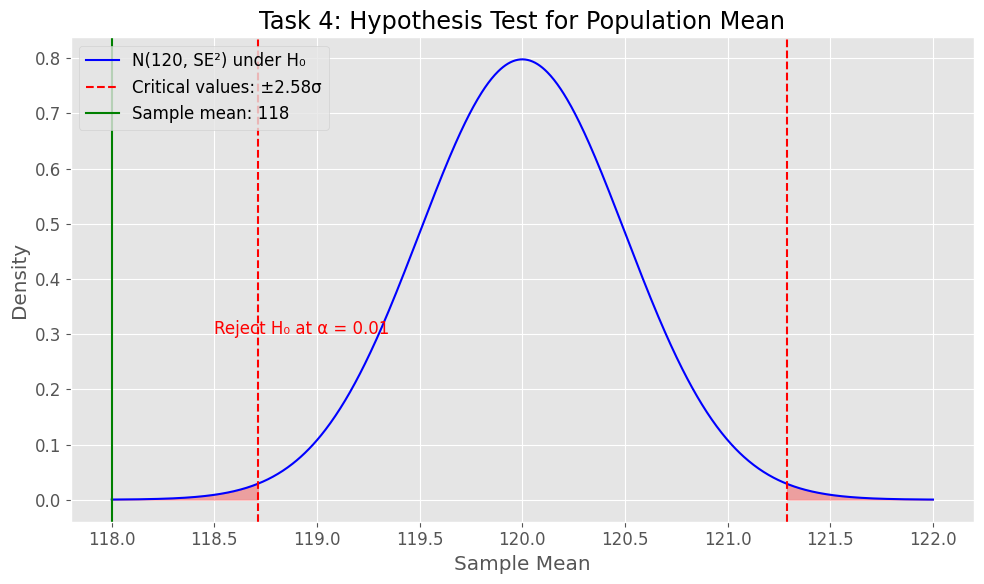

In [20]:
fig4, ax4 = plt.subplots()

x_values = np.linspace(mu0 - 4 * se, mu0 + 4 * se, 1000)
y_values = stats.norm.pdf(x_values, mu0, se)

ax4.plot(x_values, y_values, 'b-', label='N(120, SE²) under H₀')

# Fill rejection regions
x_fill_left = np.linspace(mu0 - 4 * se, x_crit_lower, 100)
y_fill_left = stats.norm.pdf(x_fill_left, mu0, se)
ax4.fill_between(x_fill_left, y_fill_left, alpha=0.3, color='red')

x_fill_right = np.linspace(x_crit_upper, mu0 + 4 * se, 100)
y_fill_right = stats.norm.pdf(x_fill_right, mu0, se)
ax4.fill_between(x_fill_right, y_fill_right, alpha=0.3, color='red')

# Add vertical lines for critical values
ax4.axvline(x=x_crit_lower, color='r', linestyle='--', label=f'Critical values: ±{z_crit:.2f}σ')
ax4.axvline(x=x_crit_upper, color='r', linestyle='--')

# Add vertical line for sample mean
ax4.axvline(x=sample_mean, color='g', linestyle='-', label=f'Sample mean: {sample_mean}')

if p_value < alpha:
    ax4.text(mu0 - 3*se, 0.3, f'Reject H₀ at α = {alpha}', fontsize=12, color='red')
else:
    ax4.text(mu0 - 3*se, 0.3, f'Fail to reject H₀ at α = {alpha}', fontsize=12, color='green')

ax4.set_xlabel('Sample Mean')
ax4.set_ylabel('Density')
ax4.set_title('Task 4: Hypothesis Test for Population Mean')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()